# Inspect wSMI outputs (NICE)

This notebook loads and visualizes per-epoch wSMI matrices saved by `scripts/compute_wsmi.py`.

Environment tip: use your general analysis env (e.g., `conda activate eeg_eng`) for viewing; only use `eeg_nice` when computing wSMI.

## Setup
- This notebook loads wSMI data from **both CSD modes** for comparison:
  - `k3_tau8ms_csd_mne` — MNE already applied CSD
  - `k3_tau8ms_csd_nice` — NICE applied CSD internally
- Each plot shows results from both modes side-by-side
- This notebook doesn't recompute anything; it only reads the computed `.npz` files

In [1]:
# Python info
import sys, platform
print('Python:', sys.executable)
print('Version:', sys.version.split()[0], '|', platform.platform())

Python: c:\Users\bmoe0112\AppData\Local\miniconda3\envs\eeg_env\python.exe
Version: 3.12.12 | Windows-11-10.0.22631-SP0


In [2]:
# Imports
import json, os, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk'); sns.set_style('whitegrid')

In [3]:
# Locate wSMI outputs robustly (handles notebook cwd)
from pathlib import Path

# Load from BOTH CSD modes for comparison
run_subdirs = ["k3_tau8ms_csd_mne", "k3_tau8ms_csd_nice"]
base_path = Path("data/processed/wsmi/events_tmin-0p2_tmax15_csd")

nb_dir = Path.cwd()
candidates_base = [
    nb_dir / base_path,
    nb_dir.parent / base_path,
    nb_dir.parent.parent / base_path,
]

# Find the correct base directory
base_root = None
for c in candidates_base:
    if c.exists():
        base_root = c
        break

if base_root is None:
    print("Checked these locations but none exist:")
    for c in candidates_base:
        print(" -", c)
    raise FileNotFoundError("Couldn't find wSMI output dir.")

# Load files from both modes
data_dict = {}
for subdir in run_subdirs:
    dir_path = base_root / subdir
    if dir_path.exists():
        files = sorted(dir_path.glob("*.npz"))
        if files:
            data_dict[subdir] = {
                'dir': dir_path,
                'files': files
            }
            print(f"✓ {subdir}: {len(files)} files")
        else:
            print(f"✗ {subdir}: No .npz files found")
    else:
        print(f"✗ {subdir}: Directory doesn't exist")

assert data_dict, "No wSMI data found in any mode!"
print(f"\nLoaded {len(data_dict)} CSD mode(s) for comparison")


✓ k3_tau8ms_csd_mne: 75 files
✓ k3_tau8ms_csd_nice: 75 files

Loaded 2 CSD mode(s) for comparison


In [4]:
# Load one file from EACH mode for comparison
loaded_data = {}

for mode_name, mode_info in data_dict.items():
    p = mode_info['files'][0]
    z = np.load(p, allow_pickle=True)
    
    loaded_data[mode_name] = {
        'wsmi': z['wsmi'],
        'events': z['events'],
        'ch_names': z['ch_names'],
        'meta': json.loads(str(z['meta'])),
        'file': p
    }
    
    print(f"\n{mode_name}:")
    print(f"  File: {p.name}")
    print(f"  wsmi: {z['wsmi'].shape} {z['wsmi'].dtype}")
    print(f"  events: {z['events'].shape}")
    print(f"  k={loaded_data[mode_name]['meta'].get('k')}, tau={loaded_data[mode_name]['meta'].get('tau_ms')}ms")



k3_tau8ms_csd_mne:
  File: patient10_raw_csd_mne_wsmi_k3_tau8ms.npz
  wsmi: (33, 19, 19) float32
  events: (33,)
  k=3, tau=8.0ms

k3_tau8ms_csd_nice:
  File: patient10_raw_csd_nice_wsmi_k3_tau8ms.npz
  wsmi: (33, 19, 19) float32
  events: (33,)
  k=3, tau=8.0ms


## Quick stats of wSMI values

### Distribution Plot - Explanation

This plot shows the distribution of all wSMI values from the upper triangle of the connectivity matrices.

**What is shown:**
- **X-axis**: wSMI values (strength of functional connectivity between channels)
- **Y-axis**: Count of observations
- **Histogram**: Number of channel pairs with given wSMI value
- **KDE curve (blue)**: Smoothed probability density

**Interpretation:**
- High wSMI values = strong information sharing between channels
- Low wSMI values = weak or no information sharing
- Distribution shape shows whether connectivity is dispersed or concentrated

k3_tau8ms_csd_mne: mean=-0.001295, std=0.004597
k3_tau8ms_csd_nice: mean=-0.001295, std=0.004597
k3_tau8ms_csd_nice: mean=-0.001295, std=0.004597


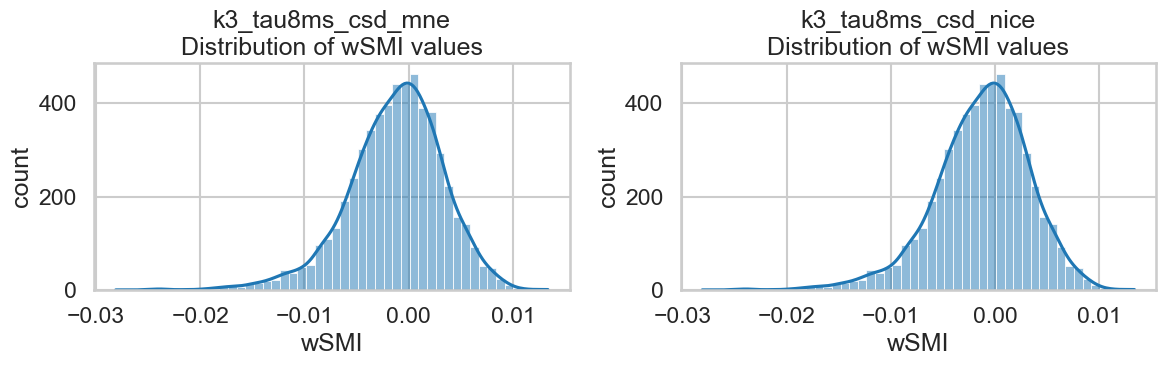

In [5]:
# Quick stats - compare both modes
fig, axes = plt.subplots(1, len(loaded_data), figsize=(6*len(loaded_data), 4))
if len(loaded_data) == 1:
    axes = [axes]

for ax, (mode_name, data) in zip(axes, loaded_data.items()):
    wsmi = data['wsmi']
    E, C, _ = wsmi.shape
    tri = np.triu_indices(C, k=1)
    vals = wsmi[:, tri[0], tri[1]].ravel()
    
    print(f'{mode_name}: mean={float(vals.mean()):.6f}, std={float(vals.std()):.6f}')
    
    sns.histplot(vals, bins=50, kde=True, ax=ax)
    ax.set_title(f'{mode_name}\nDistribution of wSMI values')
    ax.set_xlabel('wSMI')
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()


## Mean wSMI matrix across epochs

### Mean wSMI Heatmap - Explanation

This heatmap shows the average wSMI connectivity between all channels, aggregated across all epochs.

**What is shown:**
- **Each cell (i, j)**: Average wSMI between channel i and channel j
- **Darker colors**: Stronger connectivity (higher wSMI)
- **Lighter colors**: Weaker connectivity (lower wSMI)

**Interpretation:**
- Dark blocks/regions show groups of channels with strong information sharing
- These may indicate stable functional networks (e.g., frontal, parietal regions)
- Asymmetries can reveal directional information flow

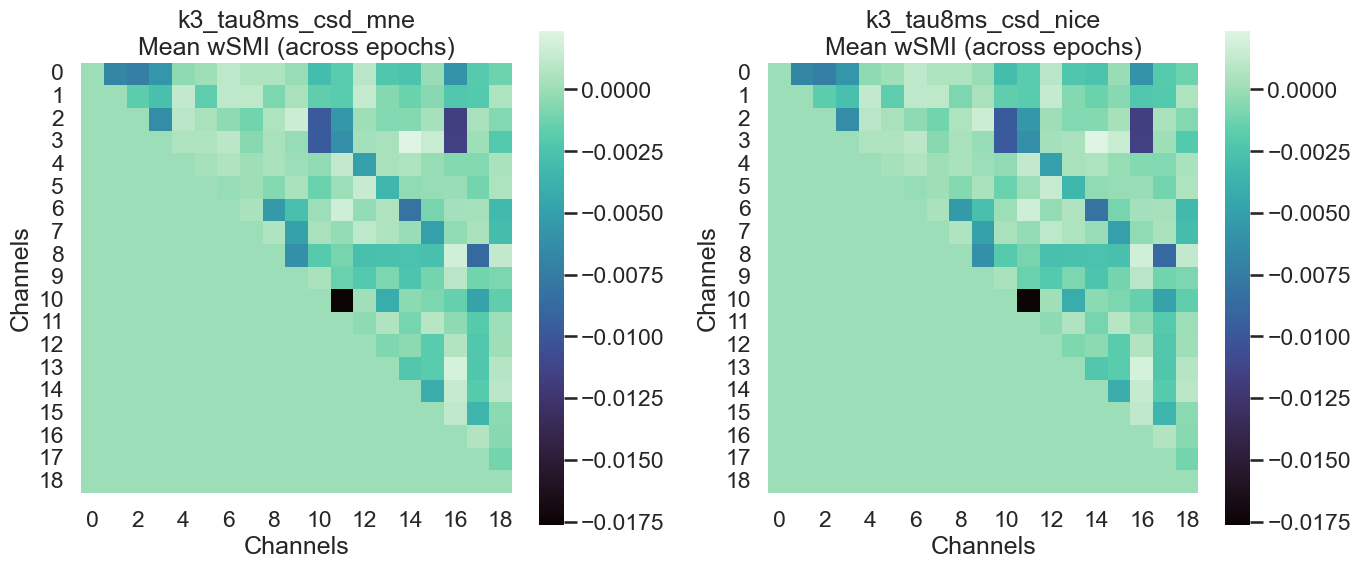

In [6]:
# Mean matrix across epochs - compare both modes
fig, axes = plt.subplots(1, len(loaded_data), figsize=(7*len(loaded_data), 6))
if len(loaded_data) == 1:
    axes = [axes]

for ax, (mode_name, data) in zip(axes, loaded_data.items()):
    wsmi = data['wsmi']
    mean_mat = wsmi.mean(axis=0)
    
    sns.heatmap(mean_mat, cmap='mako', square=True, cbar=True, ax=ax)
    ax.set_title(f'{mode_name}\nMean wSMI (across epochs)')
    ax.set_xlabel('Channels')
    ax.set_ylabel('Channels')

plt.tight_layout()
plt.show()


## Condition-Specific wSMI Matrices

### Label-Specific Heatmaps - Explanation

These heatmaps show average wSMI connectivity split by event/condition labels.

**What is shown:**
- Each plot shows only epochs with a specific label (e.g., "label 1", "label 2")
- **n=X**: the amount of meaned epochs

**Interpretation:**
- Compare patterns between labels to see connectivity differences between conditions
- Different labels may represent:
  - Different task types (e.g., rest vs. active)
  - Different stimuli or trials
  - Different clinical states
- Visual differences between labels can indicate condition-specific brain dynamics

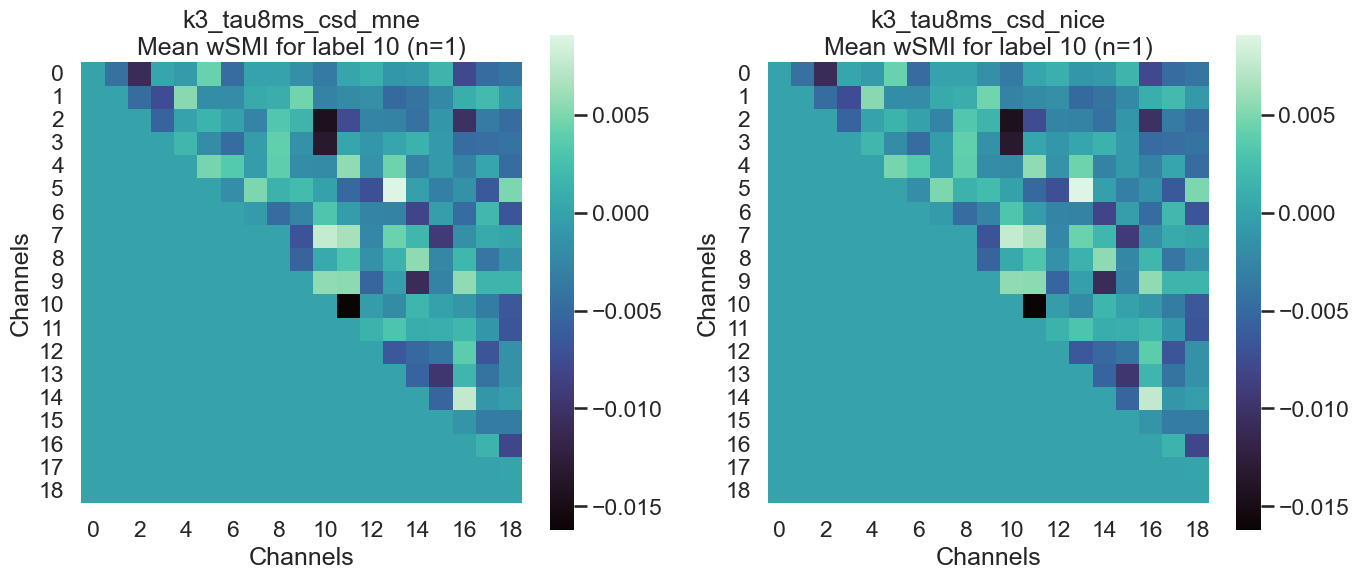

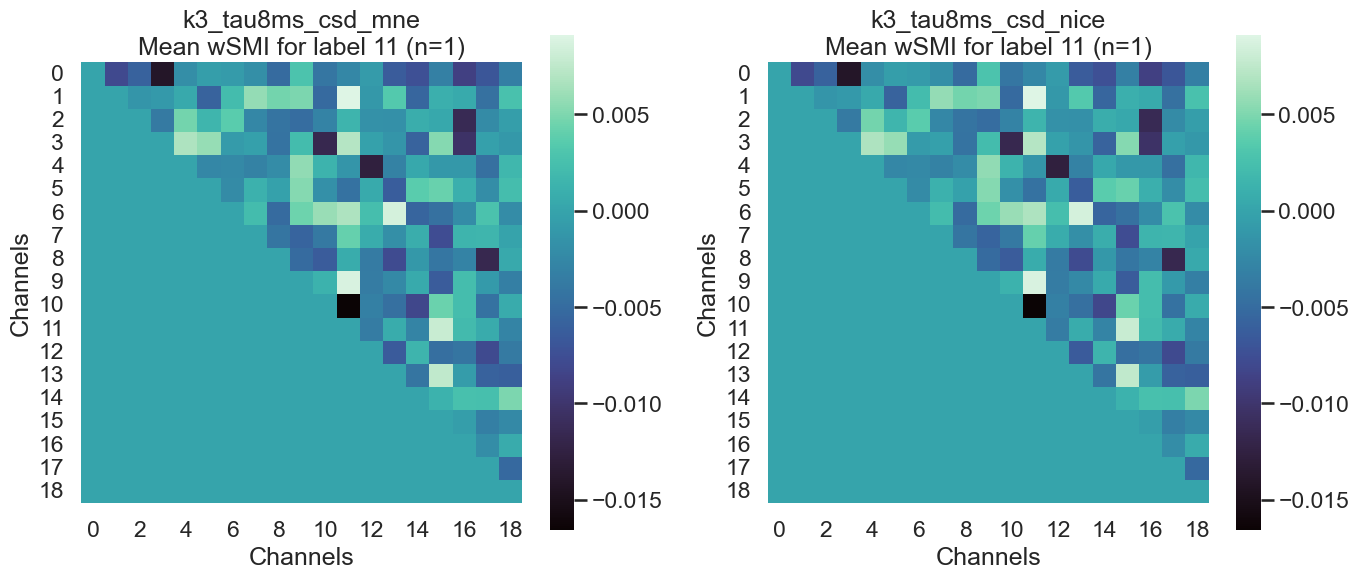

In [7]:
# Label-specific averages - compare both modes
# Get unique labels from first mode
first_mode_data = list(loaded_data.values())[0]
labs = np.unique(first_mode_data['events'])
labs = labs[:2] if len(labs) > 2 else labs

for lb in labs:
    fig, axes = plt.subplots(1, len(loaded_data), figsize=(7*len(loaded_data), 6))
    if len(loaded_data) == 1:
        axes = [axes]
    
    for ax, (mode_name, data) in zip(axes, loaded_data.items()):
        wsmi = data['wsmi']
        events = data['events']
        
        sel = (events == lb)
        if sel.sum() == 0:
            ax.text(0.5, 0.5, f'No data for label {lb}', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{mode_name}\nLabel {lb} (n=0)')
            continue
        
        mat = wsmi[sel].mean(axis=0)
        sns.heatmap(mat, cmap='mako', square=True, cbar=True, ax=ax)
        ax.set_title(f'{mode_name}\nMean wSMI for label {str(lb)} (n={int(sel.sum())})')
        ax.set_xlabel('Channels')
        ax.set_ylabel('Channels')
    
    plt.tight_layout()
    plt.show()


## Single Epoch wSMI Matrix

### Individual Epoch Heatmap - Explanation

This heatmap shows the wSMI connectivity matrix for a single epoch (time window), without any averaging.

**What is shown:**
- **One epoch**: A single 15-second time window from the recording
- **Each cell (i, j)**: wSMI between channel i and channel j during this specific epoch
- **Epoch index**: Which epoch number is being visualized (0 = first epoch, 1 = second, etc.)

**Interpretation:**
- Shows the instantaneous connectivity pattern at a specific moment in time
- More variable than averaged matrices - reflects actual brain dynamics in that window
- Can reveal transient connectivity patterns that may be smoothed out in averages
- Useful for:
  - Understanding temporal variability of connectivity
  - Identifying outlier epochs with unusual patterns
  - Examining state transitions or event-related changes

k3_tau8ms_csd_mne: epoch 0/32, label=14, range=[-0.0199, 0.0081]
k3_tau8ms_csd_nice: epoch 0/32, label=14, range=[-0.0199, 0.0081]


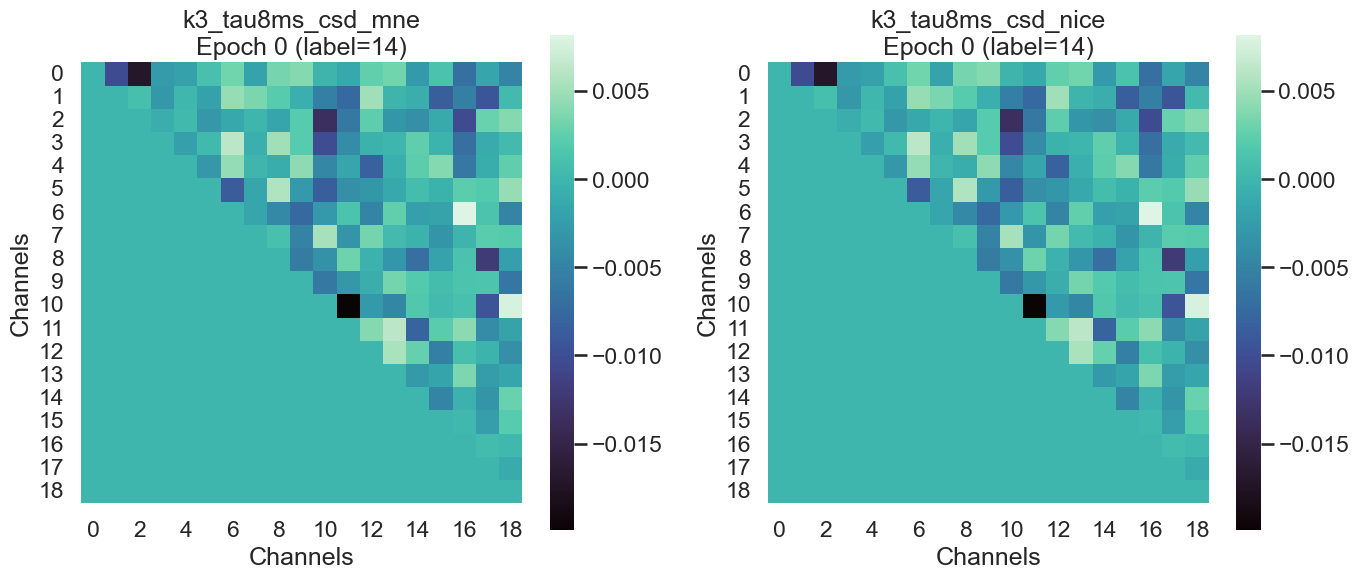

In [8]:
# Visualize single epoch - compare both modes
# Change epoch_idx to view different epochs (0 to E-1)
epoch_idx = 0  # First epoch

fig, axes = plt.subplots(1, len(loaded_data), figsize=(7*len(loaded_data), 6))
if len(loaded_data) == 1:
    axes = [axes]

for ax, (mode_name, data) in zip(axes, loaded_data.items()):
    wsmi = data['wsmi']
    events = data['events']
    E = wsmi.shape[0]
    
    # Get the wSMI matrix for this single epoch
    single_epoch_mat = wsmi[epoch_idx]  # Shape: (C, C)
    epoch_label = events[epoch_idx]
    
    print(f'{mode_name}: epoch {epoch_idx}/{E-1}, label={epoch_label}, range=[{float(single_epoch_mat.min()):.4f}, {float(single_epoch_mat.max()):.4f}]')
    
    sns.heatmap(single_epoch_mat, cmap='mako', square=True, cbar=True, ax=ax)
    ax.set_title(f'{mode_name}\nEpoch {epoch_idx} (label={epoch_label})')
    ax.set_xlabel('Channels')
    ax.set_ylabel('Channels')

plt.tight_layout()
plt.show()
